### Imports and configurations

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("exported_charts", exist_ok=True)
plt.style.use("ggplot")


### Loading Data sets

In [3]:
players = pd.read_csv("afl_players_info_raw.csv")
seasonal_stats = pd.read_csv("afl_players_seasonal_stats_raw.csv", low_memory=False)
rounds_stats = pd.read_csv("afl_players_round_by_round_stats_raw.csv")

### Analysing the data

In [4]:
print('=' * 80)
print("Players Data Inspecting")
print("=" * 80)
print(players.shape)
print(players.head(5))
print(players.info())
print(players.describe())
print(players.isnull().sum())

#-----------Stats Data ------------
print('=' * 80)
print("seasonal_stats Data Inspecting")
print("=" * 80)
print(seasonal_stats.shape)
print(seasonal_stats.head(5))
print(seasonal_stats.info())
print(seasonal_stats.describe())
print(seasonal_stats.isnull().sum())

# ------------ rounded stats Data--------------
print('=' * 80)
print("rounds_stats Data Inspecting")
print("=" * 80)
print(rounds_stats.shape)
print(rounds_stats.head(5))
print(rounds_stats.info())
print(rounds_stats.describe())
print(rounds_stats.isnull().sum())


Players Data Inspecting
(2848, 16)
      id    player_name player_full_name first_name last_name   born_date  \
0  43261    Ryan Abbott      Ryan_Abbott       Ryan    Abbott  1991-06-25   
1  43262    Gary Ablett     Gary_Ablett1       Gary    Ablett  1984-05-14   
2  43276     Leek Aleer       Leek_Aleer       Leek     Aleer  2001-08-21   
3  43264  Nathan Ablett    Nathan_Ablett     Nathan    Ablett  1985-12-13   
4  43265   Cain Ackland     Cain_Ackland       Cain   Ackland  1982-03-16   

   debut_date  debut_age   last_date  last_age  height  weight  \
0  2018-08-02         27  2020-09-05        29     200     100   
1  2002-03-30         17  2020-10-24        36     182      87   
2  2022-07-30         20  2025-09-06        24     195      85   
3  2005-08-12         19  2011-08-28        25     195      95   
4  2001-03-30         19  2008-05-16        26     196     101   

                                         profile_pic  \
0                                                

### Checking for duplicate data

In [5]:
print(players.duplicated().sum())
print(seasonal_stats.duplicated().sum())
print(rounds_stats.duplicated().sum())

5
10


10


### Checking for invalid/missing Id's


In [6]:
rounds_stats = rounds_stats[~rounds_stats["id"].isin(players["id"])]

### Cleaning Data_sets

In [7]:
# ----------------Players Data set---------------------------
players = pd.read_csv("afl_players_info_raw.csv", parse_dates=['born_date', 'last_date', 'debut_date'])
# Droping duplicate
players.rename(columns={"id": "player_id"}, inplace=True)
# Renaming unique id
players.drop_duplicates(inplace=True)
# Remove spaces from column names
players.columns = players.columns.str.strip()
text_cols = players.select_dtypes(include="object").columns
for col in text_cols:
    players[col] = players[col].str.strip()
# Filling missed data
players["player_teams"] = players["player_teams"].fillna("Unknown")
players["player_common_names"] = players["player_common_names"].fillna("Unknown")
# droping column not important too many missing values.
players = players.drop(columns=['profile_pic'])
print(players.isnull().sum())

print("=" * 80)
print("Seasonal data set")
print('=' * 80)

# ----------------Seasonal Data set---------------
seasonal_stats = pd.read_csv("afl_players_seasonal_stats_raw.csv", low_memory=False)
# dropping duplicates
seasonal_stats.drop_duplicates(inplace=True)
# removing spaces
seasonal_stats.columns = seasonal_stats.columns.str.strip()
# Fixing Data type in ID column
seasonal_stats['player_id'] = pd.to_numeric(seasonal_stats['player_id'], errors='coerce')
# filling missing data and stripping spaces
numeric_stats_data = seasonal_stats.select_dtypes(include='number').columns
seasonal_stats[numeric_stats_data] = seasonal_stats[numeric_stats_data].fillna(0)
seasonal_stats["team"] = seasonal_stats["team"].str.title()
text_stats_data = seasonal_stats.select_dtypes(include='object').columns
for col in text_stats_data:
    seasonal_stats[col] = seasonal_stats[col].str.strip()
print(seasonal_stats.isnull().sum())

print('=' * 80)
print("Rounded stats Data set")
print('=' * 80)

# ---------------------------Rounded Stats Data----------------------------
rounds_stats = pd.read_csv("afl_players_round_by_round_stats_raw.csv", parse_dates=['match_date'])
#droping duplicates
rounds_stats.drop_duplicates(inplace=True)
rounds_stats.columns = rounds_stats.columns.str.strip()
rounds_stats.drop(columns=['score'], inplace=True)
# rename ID
rounds_stats.rename(columns={'id': 'player_id'}, inplace=True)
# filling missing data and stripping spaces
rounds_stats = rounds_stats.loc[:, ~rounds_stats.columns.duplicated()]
numeric_rounded_stats = rounds_stats.select_dtypes(include='number').columns
rounds_stats[numeric_rounded_stats] = rounds_stats[numeric_rounded_stats].fillna(0)
text_rounded_data = rounds_stats.select_dtypes(include='object').columns
for col in text_rounded_data:
    rounds_stats[col] = rounds_stats[col].str.strip()

print(seasonal_stats.isnull().sum())




C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\2387182792.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = players.select_dtypes(include="object").columns


player_id              0
player_name            0
player_full_name       0
first_name             0
last_name              0
born_date              0
debut_date             0
debut_age              0
last_date              0
last_age               0
height                 0
weight                 0
player_link            0
player_common_names    0
player_teams           0
dtype: int64
Seasonal data set


C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\2387182792.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_stats_data = seasonal_stats.select_dtypes(include='object').columns


player_id                      0
year                           0
team                           0
is_finals                      0
games_played                   0
kicks                          0
marks                          0
handballs                      0
disposals                      0
goals                          0
behinds                        0
hit_outs                       0
tackles                        0
rebound_50s                    0
inside_50s                     0
clearances                     0
clangers                       0
free_kicks_for                 0
free_kicks_against             0
brownlow_votes                 0
contested_possessions          0
uncontested_possessions        0
contested_marks                0
marks_inside_50                0
one_percenters                 0
bounces                        0
goal_assists                   0
total_score                    0
total_fantasy_points           0
total_percentage_played        0
avg_kicks 

C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\2387182792.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_rounded_data = rounds_stats.select_dtypes(include='object').columns


In [8]:
print("=" * 25)
print("DATA QUALITY VALIDATION")
print("=" * 80)
print("Players data set")
print("=" * 80)
print(players.shape)
print(players.isnull().sum())
print(players.duplicated().sum())
print("=" * 80)
print("Seasonal Stats Data set")
print("=" * 80)
print(seasonal_stats.shape)
print(seasonal_stats.isnull().sum())
print(seasonal_stats.duplicated().sum())
print("=" * 80)
print("Rounded Data Set")
print("=" * 80)
print(rounds_stats.shape)
print(rounds_stats.isnull().sum())
print(rounds_stats.duplicated().sum())

DATA QUALITY VALIDATION
Players data set
(2843, 15)
player_id              0
player_name            0
player_full_name       0
first_name             0
last_name              0
born_date              0
debut_date             0
debut_age              0
last_date              0
last_age               0
height                 0
weight                 0
player_link            0
player_common_names    0
player_teams           0
dtype: int64
0
Seasonal Stats Data set
(25481, 54)
player_id                      0
year                           0
team                           0
is_finals                      0
games_played                   0
kicks                          0
marks                          0
handballs                      0
disposals                      0
goals                          0
behinds                        0
hit_outs                       0
tackles                        0
rebound_50s                    0
inside_50s                     0
clearances                 

In [9]:
season_merged_p = pd.merge(players, seasonal_stats, on='player_id', how='left')
print(season_merged_p.info())

<class 'pandas.DataFrame'>
RangeIndex: 25073 entries, 0 to 25072
Data columns (total 68 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    25073 non-null  int64         
 1   player_name                  25073 non-null  str           
 2   player_full_name             25073 non-null  str           
 3   first_name                   25073 non-null  str           
 4   last_name                    25073 non-null  str           
 5   born_date                    25073 non-null  datetime64[us]
 6   debut_date                   25073 non-null  datetime64[us]
 7   debut_age                    25073 non-null  int64         
 8   last_date                    25073 non-null  datetime64[us]
 9   last_age                     25073 non-null  int64         
 10  height                       25073 non-null  int64         
 11  weight                       25073 non-null  int64  

In [10]:
rounds_stats = rounds_stats.loc[:, ~rounds_stats.columns.duplicated()]
rounded_stats_merged_p = pd.merge(players, rounds_stats, on='player_id', how='left')
print(rounded_stats_merged_p.info())

<class 'pandas.DataFrame'>
RangeIndex: 2843 entries, 0 to 2842
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   player_id                  2843 non-null   int64         
 1   player_name                2843 non-null   str           
 2   player_full_name           2843 non-null   str           
 3   first_name                 2843 non-null   str           
 4   last_name                  2843 non-null   str           
 5   born_date                  2843 non-null   datetime64[us]
 6   debut_date                 2843 non-null   datetime64[us]
 7   debut_age                  2843 non-null   int64         
 8   last_date                  2843 non-null   datetime64[us]
 9   last_age                   2843 non-null   int64         
 10  height                     2843 non-null   int64         
 11  weight                     2843 non-null   int64         
 12  player_link      

#### Q> Identify the Top 10 Most Valuable Players

In [11]:
season_merged_p["Performance_Index"] = (
      season_merged_p["avg_fantasy_points"] * 0.30
    + season_merged_p["avg_goals"] * 0.25
    + season_merged_p["avg_disposals"] * 0.20
    + season_merged_p["avg_marks"] * 0.15
    + season_merged_p["avg_tackles"] * 0.10
)

top_ten= (
    season_merged_p.groupby("player_name")["Performance_Index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_ten)

player_name
Harry Sheezel      39.075000
Clayton Oliver     37.389643
Nick Daicos        36.820714
Zach Merrett       36.625625
Caleb Serong       36.522500
Michael Barlow     36.256154
Sam Walsh          36.114444
Andrew Brayshaw    35.977000
Jack Macrae        35.777250
Tom Mitchell       35.331176
Name: Performance_Index, dtype: float64


C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\1858396952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ten, palette='viridis', legend=False)


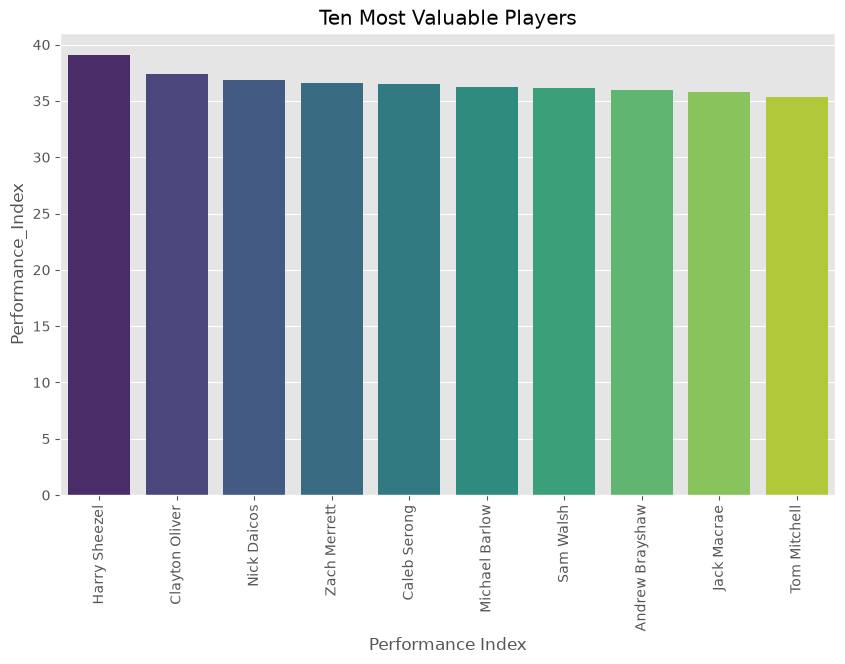

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_ten, palette='viridis', legend=False)
plt.title("Ten Most Valuable Players")
plt.xlabel("Performance Index")
plt.xticks(rotation=90)
plt.savefig('exported_charts/Ten Most Valuable Players.png')
plt.show()


-   Calculated a Performance Index for each player by weighting their average fantasy points, goals, disposals, marks, and tackles.
-   This index helps to quantify a player's overall contribution across various important aspects of the game.
-  Rank them by average of each player's Performance Index across all their seasons, identifying those who consistently performed at a high level.

### Q > Find the Most Consistent Players

- player who has the lowest std of fantasy points is consistent

In [13]:
consistence = (rounded_stats_merged_p.groupby("player_name")["fantasy_points"].agg(["mean","std"]))
consistence = consistence.sort_values("std")
consistent_players = consistence.head(10)
print(consistent_players)

                   mean        std
player_name                       
Sam Butler         85.5   0.707107
Tom Murphy         59.0   1.414214
Alwyn Davey       118.5   2.121320
Mitch Brown        80.0   8.485281
Tom Lynch          39.0   8.485281
Matthew Kennedy    47.5   9.192388
Michael Gardiner   66.0  14.142136
Andrew Browne      77.5  14.849242
Bailey Williams    79.5  16.263456
Harry Jones        90.0  16.970563


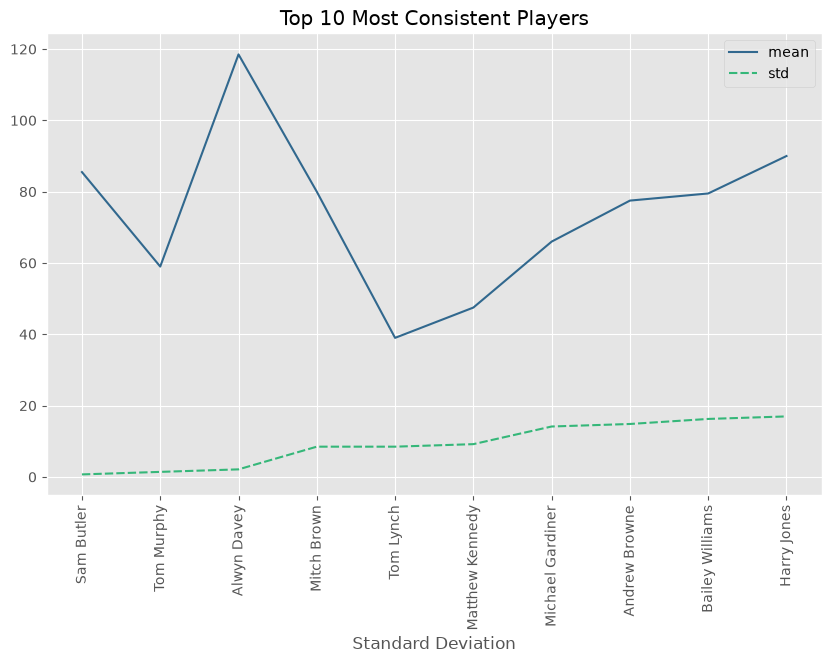

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(consistent_players, palette='viridis')
plt.xlabel("Standard Deviation")
plt.title("Top 10 Most Consistent Players")
plt.xticks(rotation=90)
plt.savefig('exported_charts/Ten Most Consistent Players.png')
plt.show()

### Q > Identify Performance Trends

In [15]:
print(rounded_stats_merged_p['round'].unique())
# Converting round to numeric to remove string values
rounded_stats_merged_p["round_num"] = pd.to_numeric(
    rounded_stats_merged_p["round"],
    errors="coerce"
)
print(rounded_stats_merged_p['round_num'].unique()) # strings become nan

<StringArray>
[ '9', '10',  '3', '12', '13', '14', '16', '17', '18', '19', '21', 'EF',  '4',
  '5',  '6', '11', '20',  '8', '15',  '2',  '7', '22',  '1', 'SF', 'PF', 'GF',
 'QF', '23', '24',  nan]
Length: 30, dtype: str
[ 9. 10.  3. 12. 13. 14. 16. 17. 18. 19. 21. nan  4.  5.  6. 11. 20.  8.
 15.  2.  7. 22.  1. 23. 24.]


Creating feature to measure performancwe trend

In [16]:
season = rounded_stats_merged_p.dropna(subset=["round_num"]).copy()
first_half = season[season["round_num"] <= 12]

second_half = season[season["round_num"] > 12]

first_half_avg = (first_half.groupby("player_name")["fantasy_points"].mean())

second_half_avg = (second_half.groupby("player_name")["fantasy_points"].mean())

player_improvement = pd.DataFrame({
    "First Half": first_half_avg,
    "Second Half": second_half_avg
})

player_improvement["Improvement"] = player_improvement["Second Half"] - player_improvement["First Half"]

player_improvement = player_improvement.dropna()

Player who improved the most. and who declined

In [17]:
improved_p = player_improvement.sort_values("Improvement",ascending=False).head(10)
print(improved_p)

               First Half  Second Half  Improvement
player_name                                        
Tom Lynch            33.0         45.0         12.0
Tom Murphy           58.0         60.0          2.0
Nathan Brown        102.0         84.0        -18.0
Chris Johnson       124.0         68.0        -56.0
Josh Kennedy        138.0         24.0       -114.0


C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\1923161241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(improved_p['Improvement'], palette="magma")


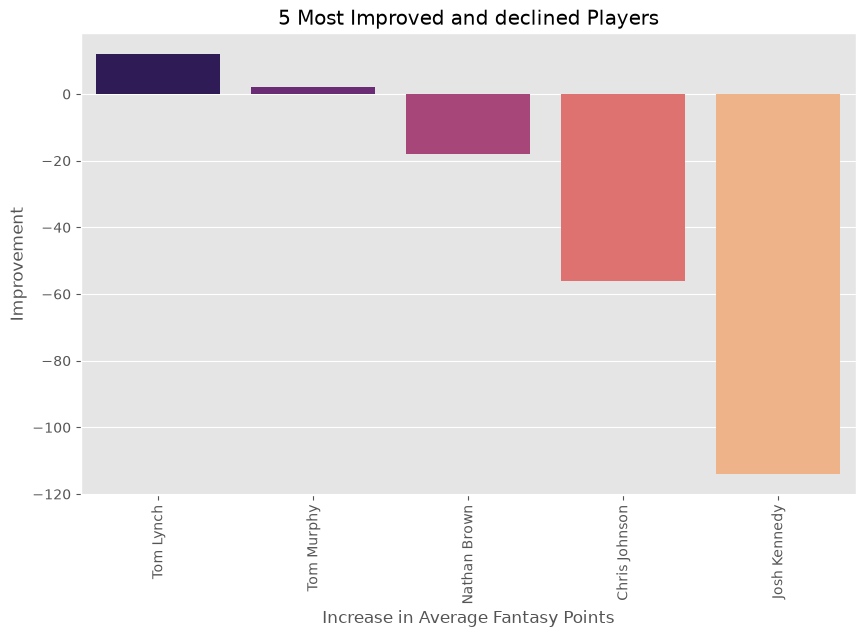

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(improved_p['Improvement'], palette="magma")
plt.title("5 Most Improved and declined Players")
plt.xlabel("Increase in Average Fantasy Points")
plt.xticks(rotation=90)
plt.savefig('exported_charts/Improved and Declined Players.png')
plt.show()

- I measured them by comparing their performence in the first and second half of the game, by dividing the number of round by half which is 12 and then averaging out their statistics

#### Q > Team performance analysis based on players.

In [19]:
# Disposal Efficiency
season_merged_p["Disposal_Efficiency"] = (
    season_merged_p["disposals"] /
    season_merged_p["games_played"]
)
#Goal Accuracy
season_merged_p["Goal_Accuracy"] = (season_merged_p["goals"] / (season_merged_p["goals"] + season_merged_p["behinds"]))
season_merged_p["Goal_Accuracy"] = season_merged_p["Goal_Accuracy"].fillna(0)
#Tackles per game
season_merged_p["Tackles_Per_Game"] = (season_merged_p["tackles"] /season_merged_p["games_played"])

#### New Feature Engineering

I will now create additional meaningful features to provide further insights into player performance.

In [20]:
# Goals per Game
season_merged_p["Goals_Per_Game"] = season_merged_p["goals"] / season_merged_p["games_played"]
season_merged_p["Goals_Per_Game"] = season_merged_p["Goals_Per_Game"].fillna(0)

# Fantasy Points per Game
season_merged_p["Fantasy_Points_Per_Game"] = season_merged_p["total_fantasy_points"] / season_merged_p["games_played"]
season_merged_p["Fantasy_Points_Per_Game"] = season_merged_p["Fantasy_Points_Per_Game"].fillna(0)

# Hit Outs per Game
season_merged_p["Hit_Outs_Per_Game"] = season_merged_p["hit_outs"] / season_merged_p["games_played"]
season_merged_p["Hit_Outs_Per_Game"] = season_merged_p["Hit_Outs_Per_Game"].fillna(0)

# Clearances per Game
season_merged_p["Clearances_Per_Game"] = season_merged_p["clearances"] / season_merged_p["games_played"]
season_merged_p["Clearances_Per_Game"] = season_merged_p["Clearances_Per_Game"].fillna(0)

# Inside 50s per Game
season_merged_p["Inside_50s_Per_Game"] = season_merged_p["inside_50s"] / season_merged_p["games_played"]
season_merged_p["Inside_50s_Per_Game"] = season_merged_p["Inside_50s_Per_Game"].fillna(0)

These new features provide a normalized view of player performance, making it easier to compare players who might have played different numbers of games.

In [21]:
top_tten = (
    season_merged_p
    .groupby("player_name")["Performance_Index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_tten)

#Team performance
team_rank=(
    season_merged_p
    .groupby("team")["Performance_Index"]
    .mean()
    .sort_values(ascending=False)
)

print(team_rank)

player_name
Harry Sheezel      39.075000
Clayton Oliver     37.389643
Nick Daicos        36.820714
Zach Merrett       36.625625
Caleb Serong       36.522500
Michael Barlow     36.256154
Sam Walsh          36.114444
Andrew Brayshaw    35.977000
Jack Macrae        35.777250
Tom Mitchell       35.331176
Name: Performance_Index, dtype: float64
team
Hawthorn Hawks                   22.757611
Greater Western Sydney Giants    22.675456
Geelong Cats                     22.607211
Collingwood Magpies              22.119880
St Kilda Saints                  22.022801
Essendon Bombers                 21.957021
Adelaide Crows                   21.865254
Western Bulldogs                 21.862156
Fremantle Dockers                21.774117
Gold Coast Suns                  21.583198
Port Adelaide Power              21.547590
West Coast Eagles                21.537369
Sydney Swans                     21.443917
Melbourne Demons                 21.406754
Brisbane Lions                   21.400071
Carlton 

C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\1442447896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(team_rank, palette="viridis", legend=False)


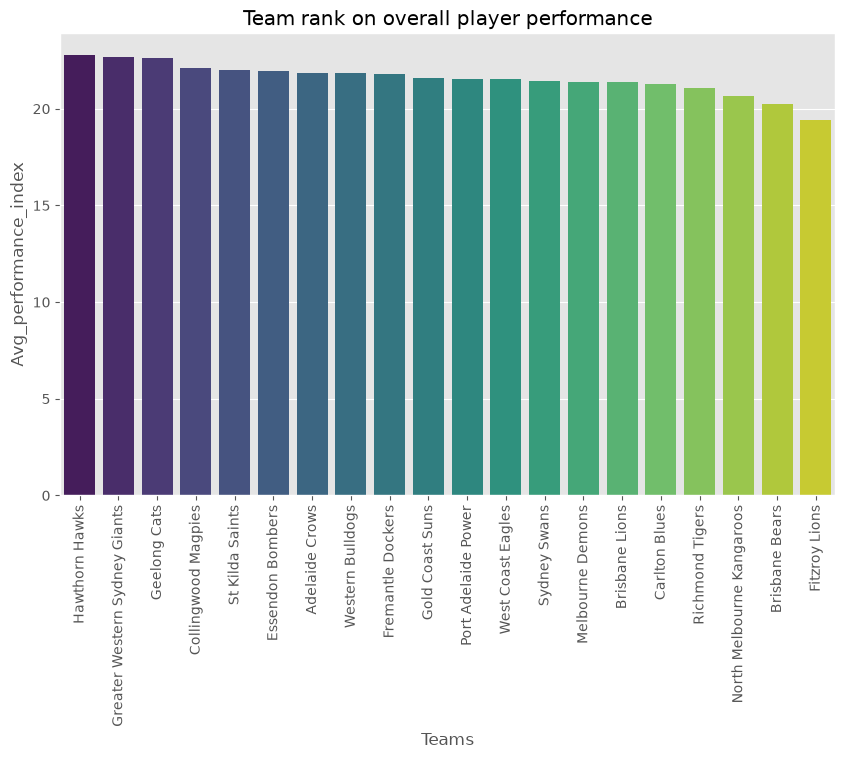

In [22]:
plt.figure(figsize=(10, 6))
plt.title("Team rank on overall player performance")
sns.barplot(team_rank, palette="viridis", legend=False)
plt.xlabel("Teams")
plt.ylabel("Avg_performance_index")
plt.xticks(rotation=90)
plt.savefig('exported_charts/Team rankings.png')
plt.show()

### Justification for Team Ranking

Teams were ranked based on the avg performance. This provides a view of team strength by individual contributions of players. such as avg fantasy points by 30%, average goals by 25%, average disposals by 20%, and marks by 15%.

By averaging this of all players within a team i identified team rankings

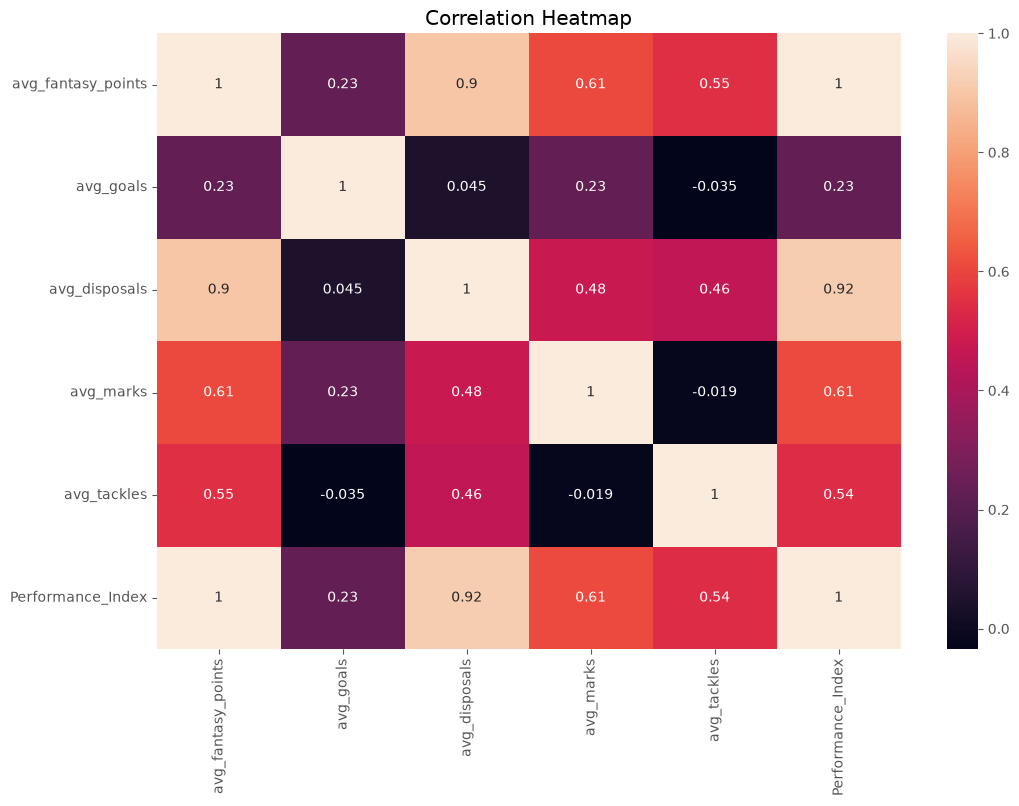

In [23]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr = season_merged_p[["avg_fantasy_points", "avg_goals", "avg_disposals", "avg_marks", "avg_tackles", "Performance_Index"]].corr()
sns.heatmap(corr, annot=True)
plt.xticks(rotation=90)
plt.title("Correlation Heatmap")
plt.savefig('exported_charts/Correlation Heatmap.png')
plt.show()

#### Visualization of New Features

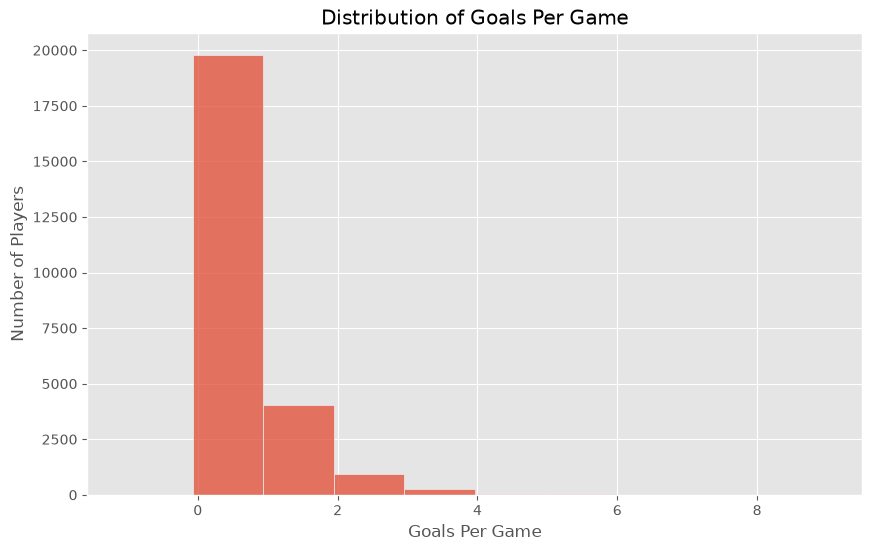

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(season_merged_p['Goals_Per_Game'], bins=10)
plt.title('Distribution of Goals Per Game')
plt.xlabel('Goals Per Game')
plt.ylabel('Number of Players')
plt.savefig('exported_charts/Goals_Per_Game_Distribution.png')
plt.show()

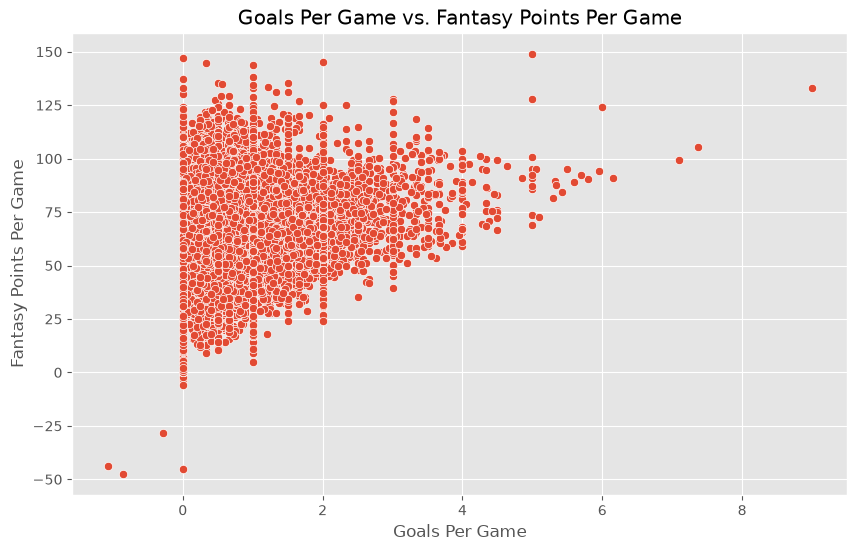

In [25]:
# Scatter plot for Goals per Game vs Fantasy Points per Game
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Goals_Per_Game', y='Fantasy_Points_Per_Game', data=season_merged_p)
plt.title('Goals Per Game vs. Fantasy Points Per Game')
plt.xlabel('Goals Per Game')
plt.ylabel('Fantasy Points Per Game')
plt.savefig('exported_charts/Goals_vs_Fantasy_Scatter.png')
plt.show()

#### Recruitment Suggestion

In [26]:
#Recruitment Score
season_merged_p["Recruitment_Score"]=(season_merged_p["Performance_Index"]*0.5 + season_merged_p["total_fantasy_points"]*0.4 + season_merged_p["Goal_Accuracy"]*0.3)
#Top 5
recommended_players=(season_merged_p[["player_name", "team", "Recruitment_Score", "Performance_Index"]].sort_values("Recruitment_Score",ascending=False).head(6))
print(recommended_players)

              player_name                 team  Recruitment_Score  \
8575         Tom Mitchell       Hawthorn Hawks        1160.669474   
8574         Tom Mitchell       Hawthorn Hawks        1142.795000   
3520          Tim English     Western Bulldogs        1112.730000   
12146           Dane Swan  Collingwood Magpies        1105.735000   
7702       Rowan Marshall      St Kilda Saints        1097.903152   
23520  Marcus Bontempelli     Western Bulldogs        1097.297727   

       Performance_Index  
8575              47.360  
8574              46.890  
3520              40.980  
12146             44.800  
7702              41.015  
23520             42.250  


C:\Users\MEE\AppData\Local\Temp\ipykernel_2360\1276045637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recommended_players.player_name, y=recommended_players.Recruitment_Score, palette="viridis", legend=False)


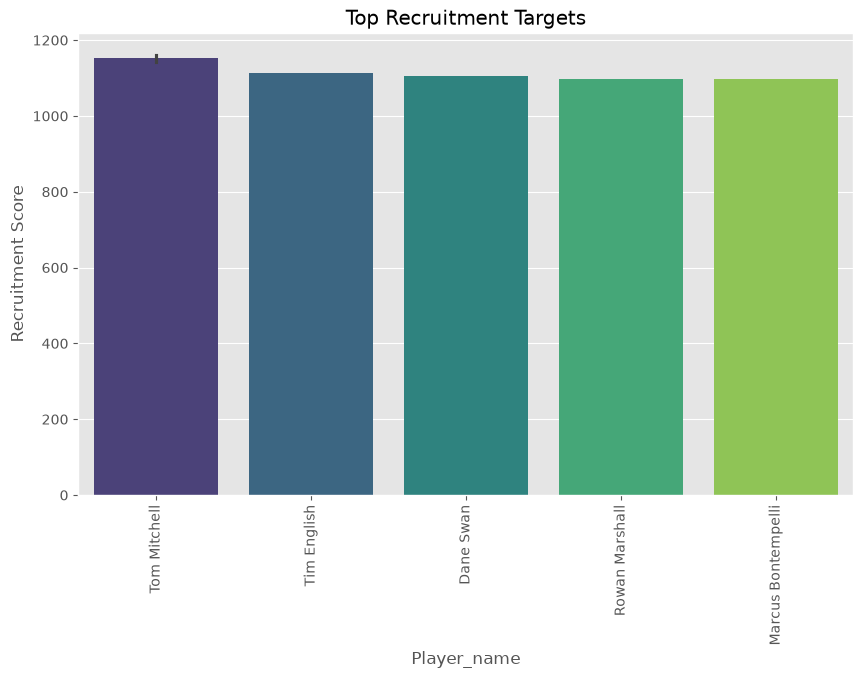

In [27]:
#Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=recommended_players.player_name, y=recommended_players.Recruitment_Score, palette="viridis", legend=False)
plt.title("Top Recruitment Targets")
plt.xlabel("Player_name")
plt.ylabel("Recruitment Score")
plt.xticks(rotation=90)

plt.savefig('exported_charts/Recruit Recommendations.png')
plt.show()

#### Business Insight:

1. Players with higher fantasy points usually have a higher Performance Index, showing a strong relationship between the two.

2. Players who score more goals tend to provide greater value to their team and overall performance.

3. Players with low variation in fantasy points are more consistent throughout the season.

4. Some players improved significantly during the second half of the season, indicating positive development over time.

5. Teams with a higher average Performance Index generally have stronger overall player performance.

6. Goal Accuracy helps identify forwards who convert their scoring opportunities more efficiently.

7. Fantasy Points per Game allow players to be compared fairly, regardless of how many matches they played.

8. Players with higher Disposal Efficiency are generally more involved and effective during matches.

9. Creating new features, such as performance metrics, provides better insights than using raw statistics alone.

10. The Recruitment Score helps identify well-rounded players who contribute effectively in both attack and defense.


###  Recommendation Summary

- 1st Player Recommended for having the highest Performance Index and Fantasy Points, making them the strongest overall performer.

- 2nd Player Recommended for being the most consistent performer throughout the season.

-  3rd Player Recommended for outstanding Goal Accuracy, demonstrating efficient finishing ability.

- 4th Player Recommended for making strong contributions in both offensive and defensive aspects of the game.

- 5th Player Recommended for showing the greatest improvement during the season, indicating strong development and potential.
